In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

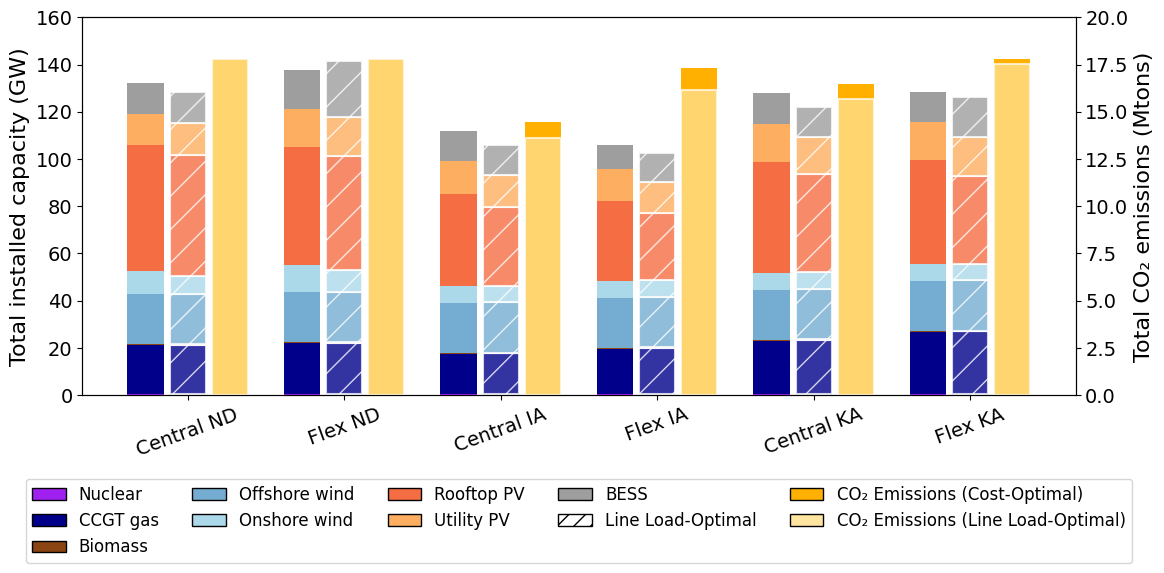

In [167]:
# Define scenario file mappings for emissions
cost_optimal_emission_files = {
    "Central ND": "co2_nd_2030_central.csv",
    "Flex ND": "co2_nd_2030_flex.csv",
    "Central IA": "co2_ia_2030_central.csv",
    "Flex IA": "co2_ia_2030_flex.csv",
    "Central KA": "co2_ka_2030_central.csv",
    "Flex KA": "co2_ka_2030_flex.csv"
}

line_load_optimal_emission_files = {
    "Central ND": "co2_nd_2030_central_ll.csv",
    "Flex ND": "co2_nd_2030_flex_ll.csv",
    "Central IA": "co2_ia_2030_central_ll.csv",
    "Flex IA": "co2_ia_2030_flex_ll.csv",
    "Central KA": "co2_ka_2030_central_ll.csv",
    "Flex KA": "co2_ka_2030_flex_ll.csv"
}

# Define scenario file mappings for capacities
cost_optimal_capacity_files = {
    "Central ND": "capacities_central_nd.csv",
    "Flex ND": "capacities_flex_nd.csv",
    "Central IA": "capacities_central_ia.csv",
    "Flex IA": "capacities_flex_ia.csv",
    "Central KA": "capacities_central_ka.csv",
    "Flex KA": "capacities_flex_ka.csv"
}

line_load_optimal_capacity_files = {
    "Central ND": "capacities_ll_central_nd.csv",
    "Flex ND": "capacities_ll_flex_nd.csv",
    "Central IA": "capacities_ll_central_ia.csv",
    "Flex IA": "capacities_ll_flex_ia.csv",
    "Central KA": "capacities_ll_central_ka.csv",
    "Flex KA": "capacities_ll_flex_ka.csv"
}

# Define technology names for better readability
tech_rename = {
    "pp_nuclear_gen3": "Nuclear",
    "pp_ccgt_gas": "CCGT gas",
    "pp_biomass_standalone": "Biomass",
    "wind_offshore": "Offshore wind",
    "wind_onshore": "Onshore wind",
    "pv_rooftop": "Rooftop PV",
    "pv_utility": "Utility PV",
    "bss_liion": "BESS"
}

# Define the order of technologies in the stacked bar
tech_order = list(tech_rename.values())

# Define colors for each technology (improved Onshore Wind color)
color_mapping = {
    "Nuclear": "#A020F0",        # Purple (Nuclear)
    "CCGT gas": "#00008B",       # Dark Blue (Fossil Gas)
    "Biomass": "#8B4513",        # Brown (Biomass)
    "Offshore wind": "#74add1",  # Light Blue (Offshore Wind)
    "Onshore wind": "#abd9e9",   # Deep Yellow (Onshore Wind - distinct from emissions)
    "Rooftop PV": "#f46d43",     # Orange (Solar Rooftop)
    "Utility PV": "#fdae61",     # Light Green (Solar Utility)
    "BESS": "#9E9E9E"            # Gray (Battery Storage)
}

# Define colors for emissions (ensuring transparency)
emission_colors = {
    "cost_optimal": "#FFB000",  # Transparent Gold
    "line_load_optimal": "#FFE5A0"  # Transparent Light Yellow
}

# Function to load and aggregate emissions
def load_emission(file_path):
    df = pd.read_csv(file_path)
    return df["carrier_prod"].values[0] / 1000 if "carrier_prod" in df.columns else None  # Convert ktons to Mtons

# Function to load and aggregate capacities per scenario
def load_and_aggregate_capacity(file_path):
    df = pd.read_csv(file_path)
    df["tech"] = df["loc_techs"].str.split("::").str[1].map(tech_rename)
    aggregated = df.groupby("tech")["energy_cap"].sum()
    return aggregated.reindex(tech_order, fill_value=0)

# Load emissions data
cost_opt_emissions = {scenario: load_emission(file) for scenario, file in cost_optimal_emission_files.items()}
line_load_emissions = {scenario: load_emission(file) for scenario, file in line_load_optimal_emission_files.items()}

# Load and aggregate capacities
cost_opt_capacities = {scenario: load_and_aggregate_capacity(file) for scenario, file in cost_optimal_capacity_files.items()}
line_load_capacities = {scenario: load_and_aggregate_capacity(file) for scenario, file in line_load_optimal_capacity_files.items()}

# Convert to DataFrame
df_emissions = pd.DataFrame({
    "Scenario": cost_opt_emissions.keys(),
    "Cost-optimal": cost_opt_emissions.values(),
    "Line load-optimal": line_load_emissions.values()
})

df_cost_capacities = pd.DataFrame(cost_opt_capacities)
df_line_load_capacities = pd.DataFrame(line_load_capacities)

# Rename for readability
df_cost_capacities.rename(index=tech_rename, inplace=True)
df_line_load_capacities.rename(index=tech_rename, inplace=True)

# Plot settings
fig, ax1 = plt.subplots(figsize=(12, 6))

bar_width = 0.3  # Bar width for capacities
emission_bar_width = 0.3  # Bar width for emissions
bar_spacing = 0.05  # Small spacing between the first two bars
scenario_spacing = 0.3  # Increase spacing between scenarios

x_labels = list(df_cost_capacities.columns)
x = np.arange(len(x_labels)) * (1 + scenario_spacing)  # Add spacing between scenarios

# Plot stacked bars for installed capacities
bottom_cost = np.zeros(len(x_labels))
bottom_line_load = np.zeros(len(x_labels))

for tech in tech_order:
    # Shift cost-optimal bars slightly left
    ax1.bar(x - bar_width - bar_spacing, df_cost_capacities.loc[tech], width=bar_width, label=tech,
            color=color_mapping.get(tech, "black"), bottom=bottom_cost)

    # Shift line load-optimal bars slightly right
    ax1.bar(x, df_line_load_capacities.loc[tech], width=bar_width, color=color_mapping.get(tech, "black"),
            bottom=bottom_line_load, hatch="/", edgecolor="white", linewidth=1.5, alpha=0.8)

    # Update bottom positions
    bottom_cost += df_cost_capacities.loc[tech]
    bottom_line_load += df_line_load_capacities.loc[tech]

# Secondary axis for CO₂ emissions
ax2 = ax1.twinx()

# Plot CO₂ emissions with the same spacing as capacity bars
ax2.bar(x + bar_width + bar_spacing, df_emissions["Cost-optimal"], width=emission_bar_width,
        color=emission_colors["cost_optimal"], label="CO₂ Emissions (Cost-Optimal)")

ax2.bar(x + bar_width + bar_spacing, df_emissions["Line load-optimal"], width=emission_bar_width,
        color=emission_colors["line_load_optimal"], label="CO₂ Emissions (Line Load-Optimal)",
        edgecolor="white", linewidth=1.5, alpha=0.7)

# Formatting
ax1.set_xticks(x)
ax1.set_xticklabels(x_labels, rotation=20, fontsize=14)

# Set y-ticks first, then set their labels
ax1.set_yticks(ax1.get_yticks())
ax1.tick_params(axis='y', labelsize=14)

ax2.set_yticks(ax2.get_yticks())
ax2.tick_params(axis='y', labelsize=14)

ax1.set_ylabel("Total installed capacity (GW)", fontsize=16)
ax2.set_ylabel("Total CO₂ emissions (Mtons)", fontsize=16)

# Create legend handles for technologies (solid color bars)
from matplotlib.patches import Patch
tech_legend_handles = [Patch(facecolor=color, edgecolor="black", label=tech) for tech, color in color_mapping.items()]

# Create custom legend handle for the line load-optimal bars (hatch)
hatch_legend_handle = Patch(facecolor="none", edgecolor="black", label="Line Load-Optimal", hatch="//")

# Create custom legend handles for emissions (NO HATCH)
emission_legend_handles = [
    Patch(facecolor=emission_colors["cost_optimal"], edgecolor="black", label="CO₂ Emissions (Cost-Optimal)"),
    Patch(facecolor=emission_colors["line_load_optimal"], edgecolor="black", label="CO₂ Emissions (Line Load-Optimal)")
]

# Combine legends for technologies, emissions, and line load hatch
legend = ax1.legend(handles=tech_legend_handles + [hatch_legend_handle] + emission_legend_handles, 
                    loc="upper center", bbox_to_anchor=(0.5, -0.2), 
                     fontsize=12, ncol=5)

plt.tight_layout()
plt.savefig("energy_cap_emission_bar.pdf", dpi=300, bbox_inches="tight")
plt.show()


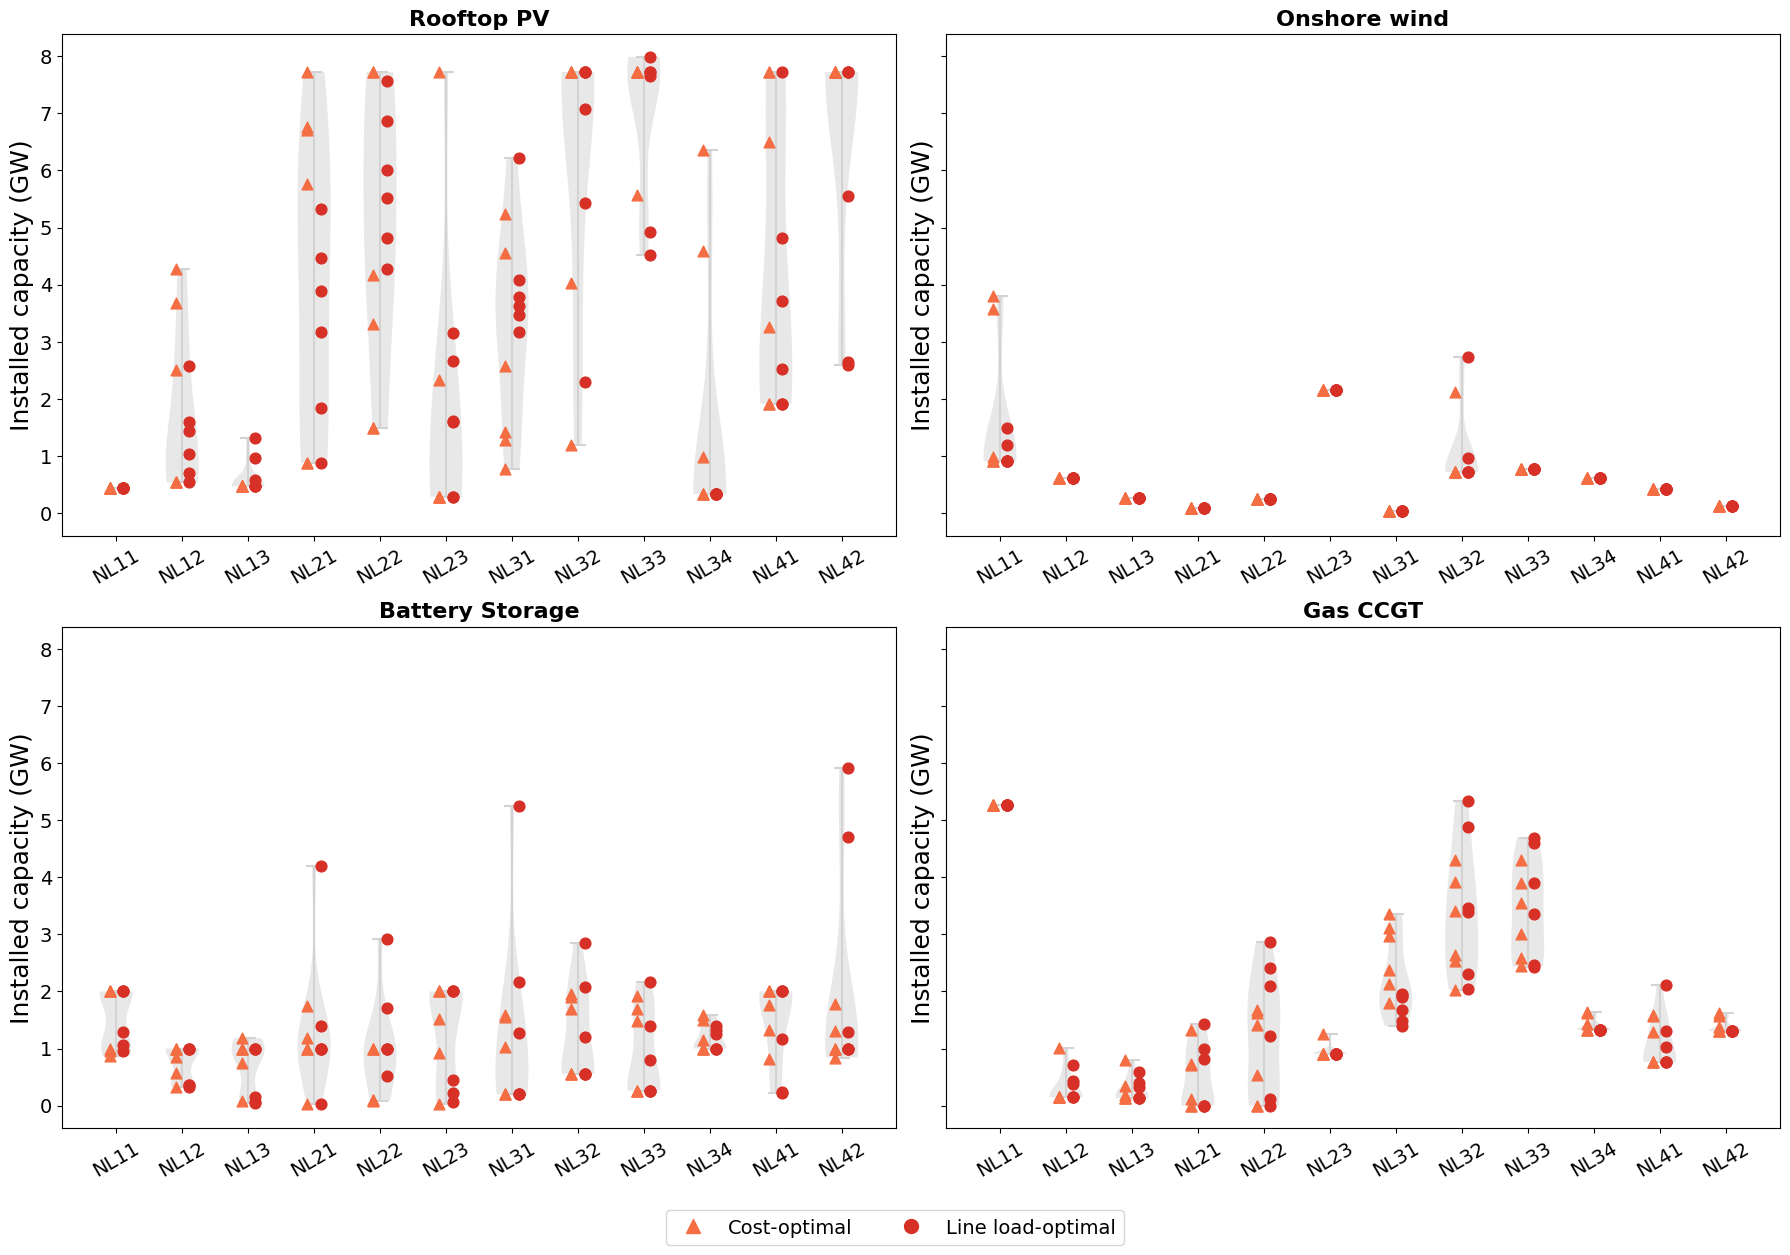

In [2]:
# Define scenario file mappings
cost_optimal_files = {
    "Central ND": "capacities_central_nd.csv",
    "Flex ND": "capacities_flex_nd.csv",
    "Central IA": "capacities_central_ia.csv",
    "Flex IA": "capacities_flex_ia.csv",
    "Central KA": "capacities_central_ka.csv",
    "Flex KA": "capacities_flex_ka.csv"
}

line_load_optimal_files = {
    "Central ND": "capacities_ll_central_nd.csv",
    "Flex ND": "capacities_ll_flex_nd.csv",
    "Central IA": "capacities_ll_central_ia.csv",
    "Flex IA": "capacities_ll_flex_ia.csv",
    "Central KA": "capacities_ll_central_ka.csv",
    "Flex KA": "capacities_ll_flex_ka.csv"
}

# Select technologies of interest (keeping Rooftop PV and Utility PV separate, if needed)
technologies = {
    "Rooftop PV": ["pv_rooftop"],
    "Onshore wind": ["wind_onshore"],
    "Battery Storage": ["bss_liion"],
    "Gas CCGT": ["pp_ccgt_gas"]
}

# Function to load and process data
def load_energy_capacities(file_path, scenario_name, opt_type):
    df = pd.read_csv(file_path)
    df["loc"] = df["loc_techs"].str.split("::").str[0]
    df["tech"] = df["loc_techs"].str.split("::").str[1]
    
    # Filter only selected technologies
    df = df[df["tech"].isin(sum(technologies.values(), []))]
    df["scenario"] = scenario_name
    df["opt_type"] = opt_type  # "Cost-optimal" or "Line load-optimal"

    # Map technology codes to display names
    df["tech"] = df["tech"].replace({tech: key for key, techs in technologies.items() for tech in techs})

    return df

# --- Load data for both cost-optimal and line-load-optimal scenarios ---
all_data = []
for scenario, file in cost_optimal_files.items():
    all_data.append(load_energy_capacities(file, scenario, "Cost-optimal"))
for scenario, file in line_load_optimal_files.items():
    all_data.append(load_energy_capacities(file, scenario, "Line load-optimal"))

df_combined = pd.concat(all_data)

# 1) Collect a GLOBAL, consistent list of locations (for consistent x-axis order)
all_locations = sorted(df_combined["loc"].unique())

# Define colors
cost_optimal_color = "#f46d43"       # e.g., orange
line_load_optimal_color = "#d73027"  # e.g., red

# Create the figure (4 subplots for the four tech categories)
fig, axes = plt.subplots(2, 2, figsize=(18, 12), sharey=True)

# Offset value to separate cost-opt and line-load opt points
scatter_offset = 0.1  

# 2) Plot each technology on a separate subplot, using the global location list
for ax, (tech_name, tech_codes) in zip(axes.flatten(), technologies.items()):
    subset = df_combined[df_combined["tech"] == tech_name]

    # We'll build the violin data in the global location order
    positions = np.arange(len(all_locations))
    violin_data = []
    
    # For each location in all_locations, get the capacity distribution
    for loc in all_locations:
        loc_data = subset[subset["loc"] == loc]["energy_cap"].values
        violin_data.append(loc_data)

    # Create the violin plot
    violin_parts = ax.violinplot(violin_data, positions=positions, showextrema=True)

    # Customize the violin appearance
    for part in violin_parts["bodies"]:
        part.set_facecolor("lightgray")
        part.set_alpha(0.5)
        part.set_zorder(1)  # behind the scatter points

    for partname in ['cbars', 'cmins', 'cmaxes']:
        violin_parts[partname].set_color("lightgray")  
        violin_parts[partname].set_zorder(1)  

    # Overlay scatter points for cost-optimal & line-load optimal
    for i, loc in enumerate(all_locations):
        # Extract scenario-specific points
        cost_opt_points = subset[(subset["loc"] == loc) & 
                                 (subset["opt_type"] == "Cost-optimal")]["energy_cap"].values
        line_load_opt_points = subset[(subset["loc"] == loc) & 
                                      (subset["opt_type"] == "Line load-optimal")]["energy_cap"].values

        ax.scatter(
            [i - scatter_offset] * len(cost_opt_points), cost_opt_points,
            color=cost_optimal_color, marker="^", s=60,
            label="Cost-Optimal" if i == 0 else "", zorder=2
        )
        ax.scatter(
            [i + scatter_offset] * len(line_load_opt_points), line_load_opt_points,
            color=line_load_optimal_color, marker="o", s=60,
            label="Line Load-Optimal" if i == 0 else "", zorder=2
        )

    # Formatting
    ax.set_title(tech_name, fontsize=16, fontweight="bold")
    ax.set_xticks(positions)
    ax.set_xticklabels(all_locations, rotation=30, fontsize=14)
    ax.set_ylabel("Installed capacity (GW)", fontsize=18)
    ax.tick_params(axis="both", which="major", labelsize=14)

# Add a global legend
handles = [
    plt.Line2D([0], [0], marker="^", color=cost_optimal_color, linestyle="None", markersize=10, label="Cost-optimal"),
    plt.Line2D([0], [0], marker="o", color=line_load_optimal_color, linestyle="None", markersize=10, label="Line load-optimal"),
]
fig.legend(handles=handles, loc="lower center", bbox_to_anchor=(0.5, -0.05), ncol=3, fontsize=14)

plt.tight_layout()
plt.savefig("energy_cap_violin.pdf", dpi=300, bbox_inches="tight")
plt.show()


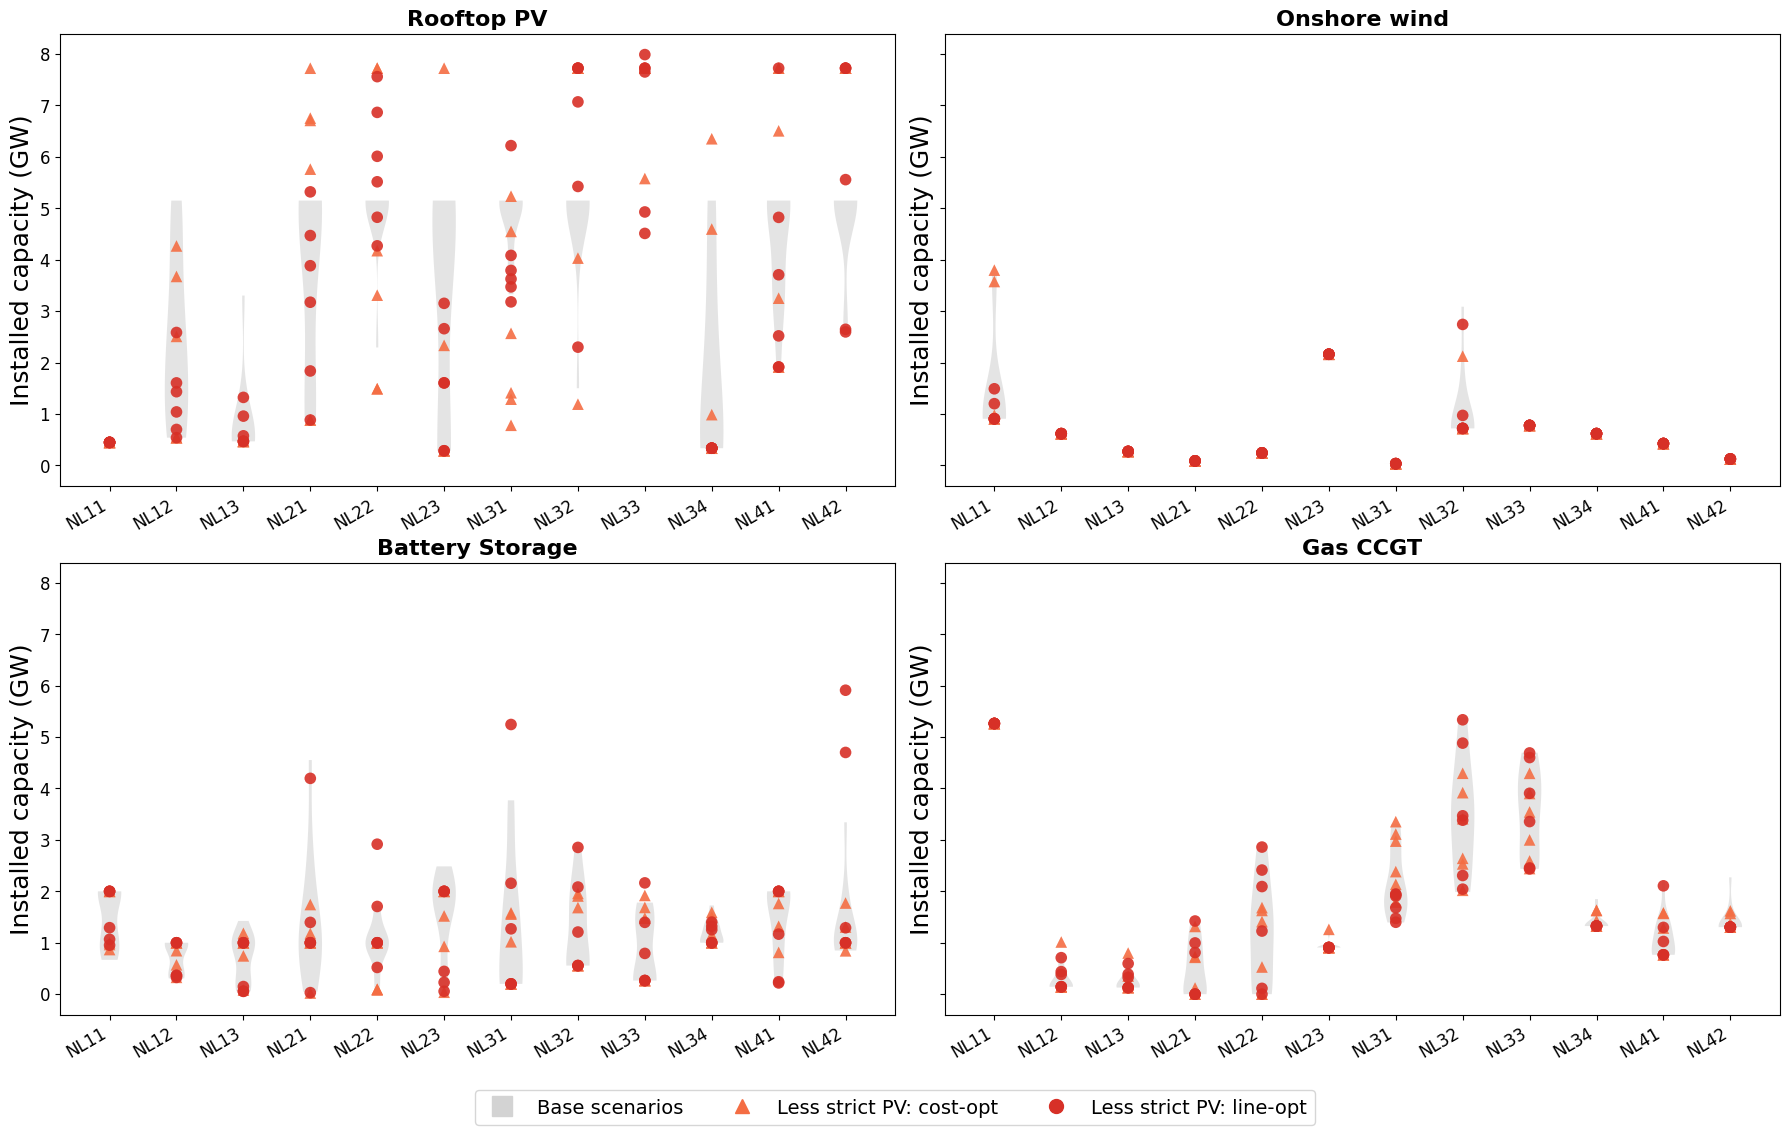

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(18, 12), sharey=True)
axes = axes.flatten()

# Violin colors
base_violin_color = "lightgray"

# Scatter colors
cost_optimal_color = "#f46d43"       # Medium orange
line_load_optimal_color = "#d73027"  # Medium red

# Horizontal offset removed (scatter must align directly over the violin)
offset = 0.2

for ax, (tech_name, _) in zip(axes, technologies.items()):
    # Subset data
    df_base_tech = df_base[df_base["tech"] == tech_name]
    df_less_tech = df_less_strict[df_less_strict["tech"] == tech_name]

    # All relevant locations
    all_locs = sorted(set(df_base_tech["loc"].unique()) | set(df_less_tech["loc"].unique()))
    x_positions = np.arange(len(all_locs))

    # Build distributions for base scenario (merging cost & line-load)
    base_dists = []
    for loc in all_locs:
        vals = df_base_tech[df_base_tech["loc"] == loc]["energy_cap"].values
        base_dists.append(vals)

    # ---------- BASE VIOLIN (light gray) ----------
    base_violin = ax.violinplot(
        base_dists,
        positions=x_positions,
        widths=0.35,
        showextrema=False,
        showmeans=False,
        showmedians=False
    )

    for body in base_violin["bodies"]:
        body.set_facecolor(base_violin_color)
        body.set_edgecolor("none")
        body.set_alpha(0.6)
        body.set_zorder(1)  # Keep violin in the background
    
    # Set entire violin plot to a lower zorder
    ax.set_zorder(0)

    # ---------- SCATTER FOR LESS STRICT (cost-opt vs line-load) ----------
    for i, loc in enumerate(all_locs):
        # Cost-opt scatter points
        cost_vals = df_less_tech[
            (df_less_tech["loc"] == loc) &
            (df_less_tech["opt_type"] == "Cost-optimal")
        ]["energy_cap"].values

        # Line-load scatter points
        line_vals = df_less_tech[
            (df_less_tech["loc"] == loc) &
            (df_less_tech["opt_type"] == "Line load-optimal")
        ]["energy_cap"].values

        # Place scatter points **directly on top of the violin** (no offset)
        ax.scatter(
            [i] * len(cost_vals),
            cost_vals,
            marker="^",
            color=cost_optimal_color,
            edgecolor="none",
            alpha=0.9,
            s=70,
            label="Less strict PV: cost-opt" if i == 0 and len(cost_vals) else None,
            zorder=3  # Ensures scatter is in front
        )

        ax.scatter(
            [i] * len(line_vals),
            line_vals,
            marker="o",
            color=line_load_optimal_color,
            edgecolor="none",
            alpha=0.9,
            s=70,
            label="Less strict PV: line-opt" if i == 0 and len(line_vals) else None,
            zorder=3  # Ensures scatter is in front
        )

    # Formatting
    ax.set_title(tech_name, fontsize=16, fontweight="bold")
    ax.set_xticks(x_positions)
    ax.set_xticklabels(all_locs, rotation=30, ha="right", fontsize=18)
    ax.set_ylabel("Installed capacity (GW)", fontsize=18)
    ax.tick_params(axis="both", which="major", labelsize=12)

# 7) BUILD A CUSTOM LEGEND
legend_handles = [
    Line2D([0], [0], marker='s', color=base_violin_color, markersize=15, 
           linestyle='', label='Base scenarios'),
    Line2D([0], [0], marker='^', color=cost_optimal_color, markersize=10,
           linestyle='', label='Less strict PV: cost-opt'),
    Line2D([0], [0], marker='o', color=line_load_optimal_color, markersize=10,
           linestyle='', label='Less strict PV: line-opt'),
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.05),
    ncol=3,
    fontsize=14
)

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)
plt.savefig("energy_cap_violin_less_strict.pdf", dpi=300, bbox_inches="tight")
plt.show()
